11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0000e+00
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0000e+00
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0000e+00
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0000e+00
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


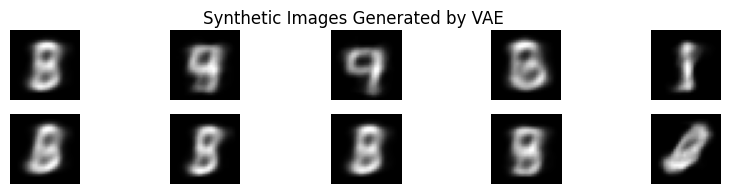

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)

# VAE dimensions
latent_dim = 2

# Encoder
encoder_inputs = tf.keras.Input(shape=(28, 28, 1))
x = tf.keras.layers.Flatten()(encoder_inputs)
x = tf.keras.layers.Dense(128, activation="relu")(x)

z_mean = tf.keras.layers.Dense(latent_dim)(x)
z_log_var = tf.keras.layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = tf.keras.layers.Lambda(sampling)([z_mean, z_log_var])

encoder = tf.keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

# Decoder
latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(128, activation="relu")(latent_inputs)
x = tf.keras.layers.Dense(28 * 28, activation="sigmoid")(x)
decoder_outputs = tf.keras.layers.Reshape((28, 28, 1))(x)

decoder = tf.keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

# VAE model
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) -
                    tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {"loss": total_loss}

# Train VAE
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

vae.fit(
    x_train,
    epochs=5,
    batch_size=128
)

# Generate synthetic images
random_latent_vectors = tf.random.normal(
    shape=(10, latent_dim)
)

generated_images = decoder.predict(random_latent_vectors)

# Visualize generated images
plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Synthetic Images Generated by VAE")
plt.show()